In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import OrdinalEncoder, StandardScaler, OneHotEncoder
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, auc
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats
from scipy.stats import chi2_contingency
from tab_transformer_pytorch import TabTransformer
from pathlib import Path
OUT_DIR = Path("output")
OUT_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
import random
random.seed(SEED); np.random.seed(SEED)
try:
    torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
except Exception:
    pass

# --- Global Settings ---
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 12, 'figure.figsize': (10, 8)})

# --- Load Data ---
# 1. Load the new master dataframe
master_df = pd.read_csv('GSE240671_master_dataframe.csv', index_col=0)

# 2. Define the new target variable 'y'
target_col = 'sentinel_lymph_node' 
target_map = {'no': 0, 'yes': 1}
y = master_df[target_col].map(target_map)

# 3. Define the new feature matrix 'X'
X = master_df.drop(columns=[target_col])

# 4. (New Step) Clean data before CV: Remove samples with missing target
valid_indices = y.dropna().index
X = X.loc[valid_indices]
y = y.loc[valid_indices]

print(f"Data for GSE240671 loaded successfully. Found {len(X)} samples.")

Data for GSE240671 loaded successfully. Found 69 samples.


In [2]:
def process_fold_features(X_train, y_train, X_test):
    """Encapsulates all feature engineering for a single fold (GSE240671 version)."""
    
    # --- 1. Process Categorical (Clinical) Features ---

    known_cat_cols = [
        'tissue', 'timing_biopsies', 'sex', 'age_diagnostic', 'patient_id',
        'statut_menopausal', 'tum_size_max_diagnostic_(larger_diameter_in_mm)',
        'molecular_category', 'ki67_binary_(1_>_and_=_15%_et_0_<15%)',
        'rcb_category', 'unifocal', 'grade', 'node_invasion', 
        'nac_category', 'nac_herceptin_binary', 'breast_conservative_surgery',
        'radiotherapy_binary', 'hormonotherapy_type_category', 
        'sequencing_batch', 'mapped_to_intergenic_(%_reads)'
    ]
    
    cat_cols = [col for col in known_cat_cols if col in X_train.columns]
    
    X_train_cat = X_train[cat_cols].copy()
    X_test_cat = X_test[cat_cols].copy()

    cols_to_drop = ['tissue', 'patient_id', 'sequencing_batch']
    X_train_cat.drop(columns=cols_to_drop, inplace=True, errors='ignore')
    X_test_cat.drop(columns=cols_to_drop, inplace=True, errors='ignore')

    numeric_cols = [
        'age_diagnostic', 
        'tum_size_max_diagnostic_(larger_diameter_in_mm)',
        'mapped_to_intergenic_(%_reads)'
    ]

    def clean_numeric_cols(df, cols):
        for col in cols:
            if col in df.columns: 
                df[col] = pd.to_numeric(df[col], errors='coerce')
        return df

    X_train_cat = clean_numeric_cols(X_train_cat, numeric_cols)
    X_test_cat = clean_numeric_cols(X_test_cat, numeric_cols)

    imputation_values = {}
    for col in X_train_cat.columns:
        if col in numeric_cols:
            imputation_values[col] = X_train_cat[col].median()
        else:
            imputation_values[col] = X_train_cat[col].mode().get(0) # .get(0)防止空mode
            
    for col, value in imputation_values.items():
        if value is not None:
            X_train_cat[col].fillna(value, inplace=True)
            X_test_cat[col].fillna(value, inplace=True)

    binned_features = []
    for col in numeric_cols:
        if col in X_train_cat.columns:
            new_col_name = f"{col}_category"

            try:
                _, bins = pd.qcut(X_train_cat[col], q=5, retbins=True, duplicates='drop')
                labels = [f'{col}_g{k + 1}' for k in range(len(bins) - 1)]
                
                for df in [X_train_cat, X_test_cat]:
                    df[new_col_name] = pd.cut(df[col], bins=bins, labels=labels, include_lowest=True)
                    df.drop(columns=[col], inplace=True)
                binned_features.append(new_col_name)
                
            except Exception as e:
                print(f"  Warning: Could not bin column {col}. Dropping it. Error: {e}")
                X_train_cat.drop(columns=[col], inplace=True, errors='ignore')
                X_test_cat.drop(columns=[col], inplace=True, errors='ignore')

    candidate_for_chi2 = X_train_cat.columns.tolist()
    selected_categorical_features = []
    
    for col in candidate_for_chi2:
        try:
            crosstab = pd.crosstab(X_train_cat[col].astype('category'), y_train)
            if crosstab.shape[0] > 1 and crosstab.shape[1] > 1:
                p_value = chi2_contingency(crosstab)[1]
                if p_value < 0.05:
                    selected_categorical_features.append(col)
        except Exception as e:
            print(f"  Skipping chi2 for {col}: {e}")

    print(f"  Selected {len(selected_categorical_features)} clinical features: {selected_categorical_features}")

    # --- 2. Process Continuous (Gene) Features ---

    gene_cols = X_train.columns.drop(cat_cols, errors='ignore')
    X_train_cont_raw = X_train[gene_cols].copy()
    X_test_cont_raw = X_test[gene_cols].copy()

    X_train_cont_raw = X_train_cont_raw.T.groupby(level=0).sum().T
    all_gene_columns = X_train_cont_raw.columns
    X_test_cont_raw = X_test_cont_raw.T.groupby(level=0).sum().T.reindex(columns=all_gene_columns, fill_value=0)

    significant_genes = []
    try:
        samples_df = pd.DataFrame({'condition': y_train})
        dds = DeseqDataSet(counts=X_train_cont_raw, metadata=samples_df, design_factors='condition')
        dds.deseq2()
        stat_res = DeseqStats(dds, contrast=['condition', 1, 0]) # 1='yes', 0='no'
        stat_res.summary()
        results_df = stat_res.results_df
        
        significant_genes = results_df[
            (results_df['padj'] < 0.05) & (abs(results_df['log2FoldChange']) > 1.0)
        ].index.tolist()
    except Exception as e:
        print(f"  DESeq2 analysis failed in this fold: {e}")

    print(f"  Found {len(significant_genes)} significant genes.")

    return X_train_cat, X_test_cat, selected_categorical_features, X_train_cont_raw, X_test_cont_raw, significant_genes


def train_tt_in_cv(X_cat_train, X_cont_train, y_train, X_cat_test, X_cont_test, cat_cardinalities):
    """
    A simplified training function for Tab-Transformer inside a CV loop.
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)
    
    model = TabTransformer(
        categories=cat_cardinalities,      
        num_continuous=X_cont_train.shape[1], 
        dim=32, dim_out=2, depth=6, heads=8 
    ).to(device)
    
    optimizer = optim.AdamW(model.parameters(), lr=1e-4)
    
    pos = float(y_train.sum())
    neg = float(len(y_train) - pos)
    if pos == 0 or neg == 0:
        w = torch.tensor([0.5, 0.5], dtype=torch.float32)
    else:
        w = torch.tensor([neg / (pos + neg), pos / (pos + neg)], dtype=torch.float32)
        
    criterion = nn.CrossEntropyLoss(weight=w.to(device))
    
    for epoch in range(50):
        model.train()
        optimizer.zero_grad()
        output = model(X_cat_train.to(device), X_cont_train.to(device))
        loss = criterion(output, y_train_tensor.to(device))
        loss.backward()
        optimizer.step()
        
    model.eval()
    with torch.no_grad():
        test_output = model(X_cat_test.to(device), X_cont_test.to(device))
        y_pred_proba = torch.softmax(test_output, dim=1).cpu().numpy()[:, 1]
        
    return y_pred_proba


print("Helper functions defined.")

Helper functions defined.


In [3]:
N_SPLITS = 5
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

# Create a dictionary to store results
results = {'AUCs': {}, 'TPRs': {}}
mean_fpr = np.linspace(0, 1, 100)
cr_macro = {}
cr_weighted = {}

# --- Start the Loop ---
for i, (train_index, test_index) in enumerate(skf.split(X, y)):
    print(f"\n========== FOLD {i + 1}/{N_SPLITS} ========== ")
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # --- 1. Perform feature engineering for the current fold ---
    X_train_cat, X_test_cat, sel_cat_feats, X_train_cont_raw, X_test_cont_raw, sig_genes = process_fold_features(
        X_train, y_train, X_test)

    # --- 2. Prepare final data subsets for this fold ---
    has_cont = (len(sig_genes) > 0)
    has_cat = (len(sel_cat_feats) > 0)
    
    # Scikit-learn data
    scaler = StandardScaler()
    onehot = OneHotEncoder(handle_unknown='ignore', sparse_output=False, dtype=int)
    
    if has_cont:
        X_train_cont_final = pd.DataFrame(scaler.fit_transform(np.log1p(X_train_cont_raw[sig_genes])), index=X_train.index, columns=sig_genes)
        X_test_cont_final = pd.DataFrame(scaler.transform(np.log1p(X_test_cont_raw[sig_genes])), index=X_test.index, columns=sig_genes)
    else:
        X_train_cont_final = pd.DataFrame(index=X_train.index)
        X_test_cont_final = pd.DataFrame(index=X_test.index)

    if has_cat:
        X_train_cat_final = pd.DataFrame(onehot.fit_transform(X_train_cat[sel_cat_feats]), index=X_train.index, columns=onehot.get_feature_names_out())
        X_test_cat_final = pd.DataFrame(onehot.transform(X_test_cat[sel_cat_feats]), index=X_test.index, columns=onehot.get_feature_names_out())
    else:
        X_train_cat_final = pd.DataFrame(index=X_train.index)
        X_test_cat_final = pd.DataFrame(index=X_test.index)
        
    X_train_comb = pd.concat([X_train_cat_final, X_train_cont_final], axis=1)
    X_test_comb = pd.concat([X_test_cat_final, X_test_cont_final], axis=1)

    # Tab-Transformer data
    if has_cat:
        ordinal = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1);
        ordinal.fit(X_train_cat[sel_cat_feats])
        X_train_cat_ord = torch.tensor(ordinal.transform(X_train_cat[sel_cat_feats]), dtype=torch.long)
        X_test_cat_ord = torch.tensor(ordinal.transform(X_test_cat[sel_cat_feats]), dtype=torch.long)
        cat_cards = [len(cats) for cats in ordinal.categories_]
    else:
        X_train_cat_ord = torch.empty(len(X_train), 0, dtype=torch.long)
        X_test_cat_ord = torch.empty(len(X_test), 0, dtype=torch.long)
        cat_cards = []

    if has_cont:
        X_train_cont_tensor = torch.tensor(X_train_cont_final.values, dtype=torch.float32)
        X_test_cont_tensor = torch.tensor(X_test_cont_final.values, dtype=torch.float32)
    else:
        X_train_cont_tensor = torch.empty(len(X_train), 0)
        X_test_cont_tensor = torch.empty(len(X_test), 0)

    # --- 3. Run all experiments for this fold ---
    models_to_run = {}
    
    if has_cont:
        models_to_run['TT_cont'] = lambda: train_tt_in_cv(
            torch.empty(len(X_train), 0, dtype=torch.long), X_train_cont_tensor, y_train,
            torch.empty(len(X_test), 0, dtype=torch.long), X_test_cont_tensor, [])
        models_to_run['RF_cont'] = lambda: RandomForestClassifier(
            n_estimators=100, random_state=42, n_jobs=-1, class_weight="balanced_subsample"
        ).fit(X_train_cont_final, y_train).predict_proba(X_test_cont_final)[:, 1]
        models_to_run['LR_cont'] = lambda: LogisticRegression(
            random_state=42, max_iter=1000, class_weight="balanced"
        ).fit(X_train_cont_final, y_train).predict_proba(X_test_cont_final)[:, 1]
        models_to_run['LASSO_cont'] = lambda: LogisticRegression(
            penalty='l1', solver='liblinear', C=1.0, random_state=42, class_weight="balanced"
        ).fit(X_train_cont_final, y_train).predict_proba(X_test_cont_final)[:, 1]

    if has_cat:
        models_to_run['TT_cat'] = lambda: train_tt_in_cv(
            X_train_cat_ord, torch.empty(len(X_train), 0), y_train, X_test_cat_ord, torch.empty(len(X_test), 0),
            cat_cards)

    if has_cat and has_cont:
        models_to_run['TT_comb'] = lambda: train_tt_in_cv(
            X_train_cat_ord, X_train_cont_tensor, y_train,
            X_test_cat_ord, X_test_cont_tensor, cat_cards
        )
        models_to_run['RF_comb'] = lambda: RandomForestClassifier(
            n_estimators=100, random_state=42, n_jobs=-1, class_weight="balanced_subsample"
        ).fit(X_train_comb, y_train).predict_proba(X_test_comb)[:, 1]
        models_to_run['LR_comb'] = lambda: LogisticRegression(
            random_state=42, max_iter=1000, class_weight="balanced"
        ).fit(X_train_comb, y_train).predict_proba(X_test_comb)[:, 1]
        models_to_run['LASSO_comb'] = lambda: LogisticRegression(
            penalty='l1', solver='liblinear', C=1.0, random_state=42, class_weight="balanced"
        ).fit(X_train_comb, y_train).predict_proba(X_test_comb)[:, 1]

    
    if not models_to_run:
        print(f"  Fold {i+1} skipped: No 'cat' or 'cont' features were found.")
        continue

    for name, train_eval_func in models_to_run.items():
        if name not in results['AUCs']:
            results['AUCs'][name] = []
            results['TPRs'][name] = []
            cr_macro[name] = []
            cr_weighted[name] = []

        y_proba = train_eval_func()
        auc_score = roc_auc_score(y_test, y_proba)
        results['AUCs'][name].append(auc_score)

        fpr, tpr, _ = roc_curve(y_test, y_proba)
        interp_tpr = np.interp(mean_fpr, fpr, tpr)
        interp_tpr[0] = 0.0
        results['TPRs'][name].append(interp_tpr)
        print(f"  {name}: AUC = {auc_score:.4f}")
        
        y_pred = (y_proba >= 0.5).astype(int)
        cr = classification_report(y_test, y_pred, output_dict=True, zero_division=0)

        cr_macro[name].append([
            cr["macro avg"]["precision"], cr["macro avg"]["recall"], cr["macro avg"]["f1-score"],
        ])
        cr_weighted[name].append([
            cr["weighted avg"]["precision"], cr["weighted avg"]["recall"], cr["weighted avg"]["f1-score"],
        ])

print("\n========== CROSS-VALIDATION COMPLETE ==========")


========== FOLD 1/5 ========== 
  Selected 2 clinical features: ['node_invasion', 'tum_size_max_diagnostic_(larger_diameter_in_mm)_category']


C:\Users\27694\AppData\Local\Temp\ipykernel_26696\2256886894.py:119: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
  dds = DeseqDataSet(counts=X_train_cont_raw, metadata=samples_df, design_factors='condition')
Fitting size factors...
... done in 0.09 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 3.42 seconds.

Fitting dispersion trend curve...
... done in 0.68 seconds.

Fitting MAP dispersions...
... done in 3.66 seconds.

Fitting LFCs...
... done in 3.41 seconds.

Calculating cook's distance...
... done in 0.22 seconds.

Replacing 1134 outlier genes.

Fitting dispersions...
... done in 0.49 seconds.

Fitting MAP dispersions...
... done in 0.50 seconds.

Fitting LFCs...
... done in 0.50 seconds.

Running Wald tests...
... done in 2.66 seconds.



Log2 fold change & Wald test p-value: condition 1 vs 0
             baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
A1BG        78.284972       -0.256521  0.237335 -1.080839  0.279769  0.855351
A1BG-AS1    91.196576       -0.285132  0.212356 -1.342705  0.179367  0.777512
A1CF        54.882002       -0.252840  0.608259 -0.415678  0.677646  0.978861
A2M       1642.330787        0.281857  0.263264  1.070622  0.284339  0.856625
A2M-AS1     71.806845        0.347439  0.276290  1.257518  0.208566  0.805421
...               ...             ...       ...       ...       ...       ...
ZYG11A     153.073157        0.558635  0.368133  1.517480  0.129145  0.717434
ZYG11B     394.015157       -0.271325  0.141281 -1.920461  0.054800  0.584461
ZYX        492.584436        0.214842  0.232777  0.922952  0.356032  0.897934
ZZEF1     1489.731909        0.009062  0.136093  0.066585  0.946912  0.998637
ZZZ3       565.403840       -0.340386  0.137064 -2.483404  0.013013  0.385776

[39376 r

...

Log2 fold change & Wald test p-value: condition 1 vs 0
             baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
A1BG        82.203502       -0.120837  0.225382 -0.536141  0.591861  0.862625
A1BG-AS1    89.795388       -0.103635  0.245333 -0.422428  0.672713  0.894236
A1CF        53.343603       -0.100721  0.621058 -0.162176  0.871167  0.961036
A2M       2028.167205       -0.115350  0.347809 -0.331648  0.740155  0.919669
A2M-AS1     76.440551        0.024626  0.290279  0.084837  0.932391  0.979987
...               ...             ...       ...       ...       ...       ...
ZYG11A     160.939562        0.599633  0.385923  1.553762  0.120241  0.526536
ZYG11B     400.893070       -0.356139  0.144871 -2.458324  0.013959  0.250668
ZYX        511.047087        0.195946  0.227508  0.861274  0.389087  0.752919
ZZEF1     1545.135923        0.084352  0.141768  0.594998  0.551845  0.841400
ZZZ3       588.471243       -0.212756  0.146546 -1.451802  0.146557  0.562800

[39376 r

C:\Users\27694\AppData\Local\Temp\ipykernel_26696\2256886894.py:119: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
  dds = DeseqDataSet(counts=X_train_cont_raw, metadata=samples_df, design_factors='condition')
Fitting size factors...
... done in 0.09 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 3.40 seconds.

Fitting dispersion trend curve...
... done in 0.70 seconds.

Fitting MAP dispersions...
... done in 3.52 seconds.

Fitting LFCs...
... done in 3.29 seconds.

Calculating cook's distance...
... done in 0.19 seconds.

Replacing 1111 outlier genes.

Fitting dispersions...
... done in 0.51 seconds.

Fitting MAP dispersions...
... done in 0.45 seconds.

Fitting LFCs...
... done in 0.46 seconds.

Running Wald tests...
... done in 2.73 seconds.



Log2 fold change & Wald test p-value: condition 1 vs 0
             baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
A1BG        82.453994       -0.202551  0.214746 -0.943212  0.345573  0.845931
A1BG-AS1    91.483345       -0.223432  0.222057 -1.006193  0.314323  0.828088
A1CF        57.083514       -0.079957  0.606814 -0.131765  0.895170  0.989001
A2M       2070.265913        0.136018  0.334552  0.406566  0.684327  0.947519
A2M-AS1     81.560557        0.227646  0.282947  0.804552  0.421078  0.877547
...               ...             ...       ...       ...       ...       ...
ZYG11A     155.072271        0.618802  0.373042  1.658801  0.097156  0.655968
ZYG11B     396.967120       -0.279289  0.142550 -1.959243  0.050084  0.568032
ZYX        502.278616        0.221297  0.221394  0.999561  0.317523  0.830667
ZZEF1     1528.631329        0.000828  0.130221  0.006360  0.994925  0.999069
ZZZ3       567.264725       -0.166053  0.144064 -1.152628  0.249063  0.790722

[39376 r

In [4]:
def _cr_store_to_df(store: dict, label: str) -> pd.DataFrame:
    rows = []
    for name, arr in store.items():
        A = np.asarray(arr, dtype=float)
        mu = A.mean(axis=0); sd = A.std(axis=0)
        rows.append([
            name.replace("_", " ").title(),
            mu[0], sd[0], mu[1], sd[1], mu[2], sd[2],
        ])
    return pd.DataFrame(rows, columns=[
        "Model",
        f"{label} Precision (mean)", f"{label} Precision (std)",
        f"{label} Recall (mean)",    f"{label} Recall (std)",
        f"{label} F1 (mean)",        f"{label} F1 (std)",
    ]).sort_values("Model").reset_index(drop=True)

# --- AUC Summary Table ---
summary_data = []
for name, auc_list in results['AUCs'].items():
    summary_data.append({
        'Experiment': name.replace("_", " ").title(),
        'Mean AUC': np.mean(auc_list),
        'Std Dev (±)': np.std(auc_list)
    })

summary_cv_df = pd.DataFrame(summary_data).set_index('Experiment').sort_values(by='Mean AUC', ascending=False)

print("\n--- Final Cross-Validation Performance Summary (GSE240671) ---")
print("Metrics are reported as Mean ± Standard Deviation over 5 folds.")

try:
    display(summary_cv_df.style
            .format({'Mean AUC': '{:.3f}', 'Std Dev (±)': '{:.3f}'})
            .background_gradient(cmap='Greens', subset=['Mean AUC'])
            .bar(subset=['Std Dev (±)'], color='#d4edda', align='zero')
    )
except:
    print(summary_cv_df)

summary_cv_path = OUT_DIR / "GSE240671_cv_auc_summary.csv"
summary_cv_df.to_csv(summary_cv_path, index=True)
print(f"Saved CV AUC summary to: {summary_cv_path}")

# --- Classification Report Tables ---
macro_df = _cr_store_to_df(cr_macro, "Macro")
weighted_df = _cr_store_to_df(cr_weighted, "Weighted")

print("\n--- Classification Report (Macro avg) — 5-fold mean ± std ---")
try: display(macro_df)
except: print(macro_df)
print("\n--- Classification Report (Weighted avg) — 5-fold mean ± std ---")
try: display(weighted_df)
except: print(weighted_df)

macro_path = OUT_DIR / "GSE240671_cv_classification_report_macro.csv"
weighted_path = OUT_DIR / "GSE240671_cv_classification_report_weighted.csv"
macro_df.to_csv(macro_path, index=False)
weighted_df.to_csv(weighted_path, index=False)
print(f"Saved CR tables to:\n- {macro_path}\n- {weighted_path}")


--- Final Cross-Validation Performance Summary (GSE240671) ---
Metrics are reported as Mean ± Standard Deviation over 5 folds.


,Mean AUC,Std Dev (±)
Experiment,,
Tt Comb,0.876,0.068
Tt Cat,0.809,0.103
Lasso Comb,0.800,0.129
Rf Comb,0.782,0.073
Lr Comb,0.752,0.052
Lr Cont,0.715,0.102
Lasso Cont,0.661,0.131
Tt Cont,0.639,0.273
Rf Cont,0.605,0.061


Saved CV AUC summary to: output\GSE240671_cv_auc_summary.csv

--- Classification Report (Macro avg) — 5-fold mean ± std ---


,Model,Macro Precision (mean),Macro Precision (std),Macro Recall (mean),Macro Recall (std),Macro F1 (mean),Macro F1 (std)
0,Lasso Comb,0.763100,0.140605,0.728788,0.140215,0.725866,0.124449
1,Lasso Cont,0.630346,0.145402,0.666667,0.161490,0.631350,0.150558
2,Lr Comb,0.745676,0.130708,0.695455,0.095153,0.702489,0.096486
3,Lr Cont,0.672020,0.115266,0.692424,0.145139,0.670247,0.125620
4,Rf Comb,0.455195,0.124675,0.540909,0.081818,0.492909,0.105818
5,Rf Cont,0.501648,0.211189,0.515152,0.078437,0.488000,0.111272
6,Tt Cat,0.615476,0.210671,0.598485,0.093154,0.592232,0.140064
7,Tt Comb,0.615476,0.210671,0.598485,0.093154,0.592232,0.140064
8,Tt Cont,0.477381,0.178111,0.572727,0.194129,0.517499,0.180335



--- Classification Report (Weighted avg) — 5-fold mean ± std ---


,Model,Weighted Precision (mean),Weighted Precision (std),Weighted Recall (mean),Weighted Recall (std),Weighted F1 (mean),Weighted F1 (std)
0,Lasso Comb,0.842198,0.087274,0.826374,0.096340,0.824503,0.089664
1,Lasso Cont,0.785107,0.084652,0.753846,0.106225,0.756919,0.096272
2,Lr Comb,0.824341,0.071901,0.812088,0.084722,0.809537,0.075623
3,Lr Cont,0.800024,0.088620,0.768132,0.104736,0.776866,0.094780
4,Rf Comb,0.663108,0.091523,0.797802,0.024176,0.722374,0.061890
5,Rf Cont,0.684247,0.106029,0.783516,0.061538,0.720795,0.069212
6,Tt Cat,0.737598,0.115692,0.813187,0.054945,0.766535,0.080539
7,Tt Comb,0.737598,0.115692,0.813187,0.054945,0.766535,0.080539
8,Tt Cont,0.678009,0.135790,0.784615,0.088623,0.723626,0.106848


Saved CR tables to:
- output\GSE240671_cv_classification_report_macro.csv
- output\GSE240671_cv_classification_report_weighted.csv



--- Generating Plot 1: Mean ROC Curves on Continuous Features Only (GSE240671) ---
Saved figure to: output\GSE240671_cv_roc_only_continuous.png


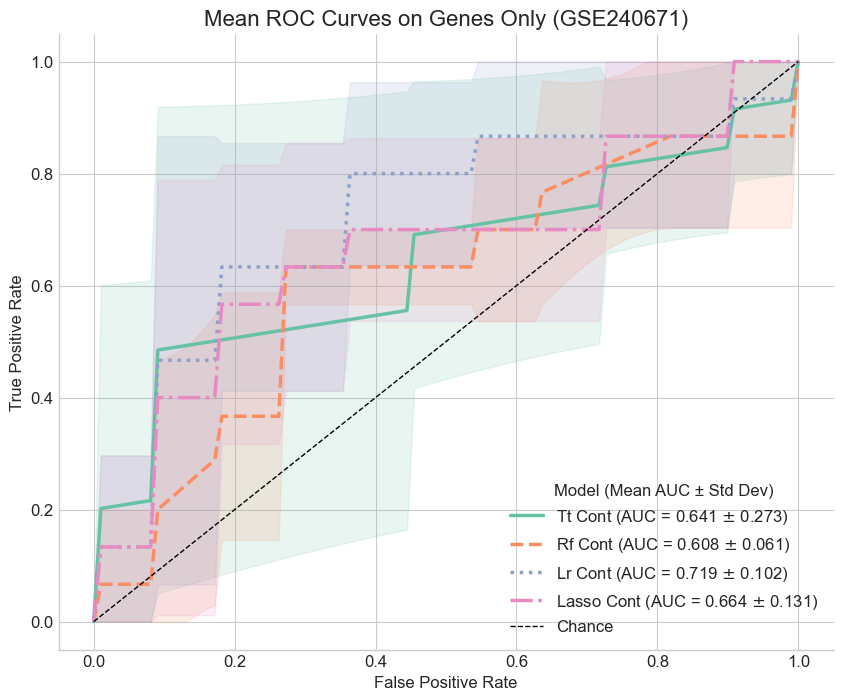


--- Generating Plot 2: Tab-Transformer Ablation Study (GSE240671) ---
Saved figure to: output\GSE240671_cv_roc_tt_internal.png


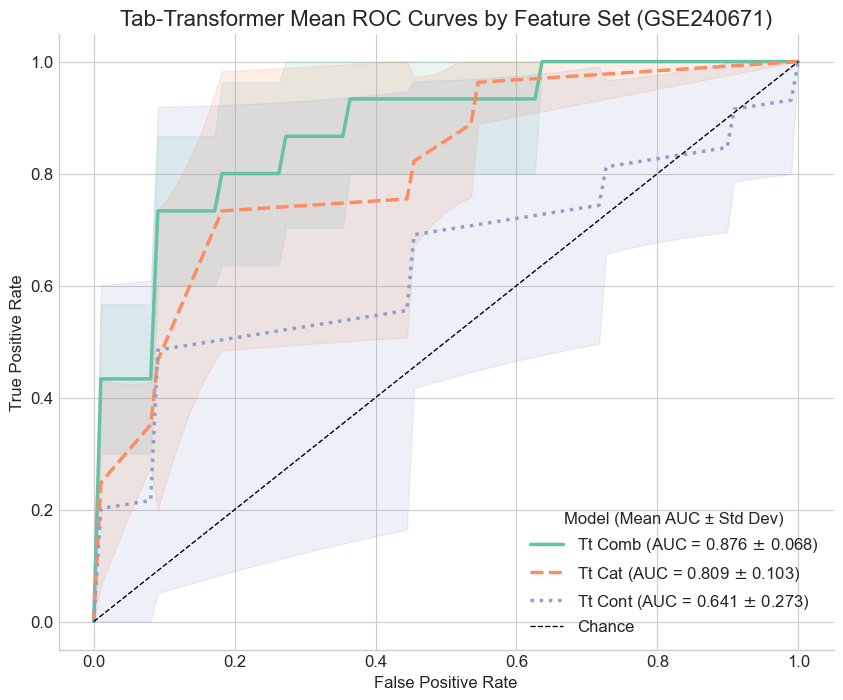


--- Generating Plot 3: Final Model Showdown on Combined Features (GSE240671) ---
Saved figure to: output\GSE240671_cv_roc_combined.png


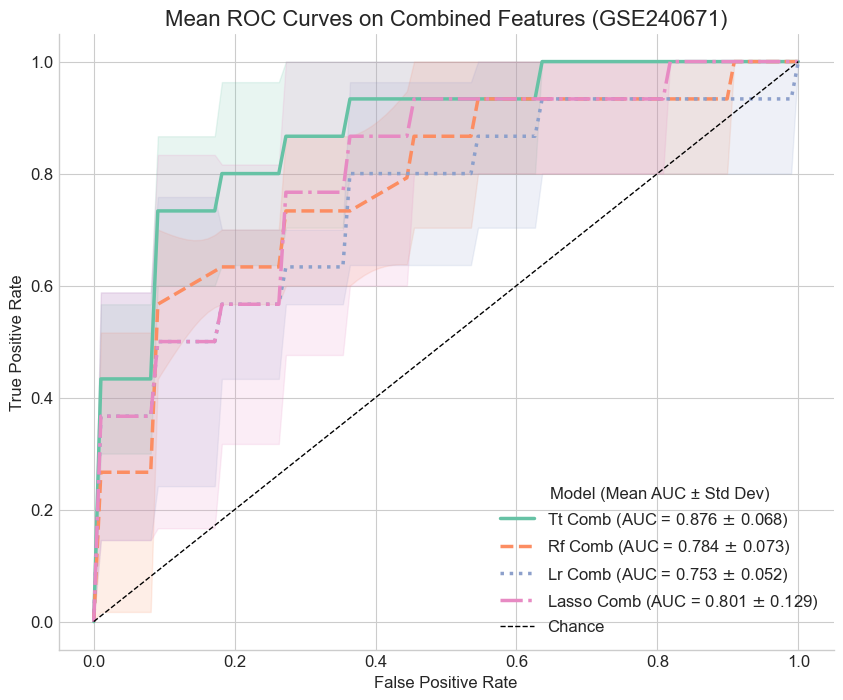

In [5]:
def plot_mean_roc_curves_with_std(results_tprs, results_aucs, model_keys, title, save_path=None):
    """
    Helper function to plot multiple mean ROC curves from CV results,
    including a shaded standard deviation band for each curve.
    """
    plt.figure(figsize=(10, 8))
    colors = sns.color_palette('Set2', n_colors=len(model_keys))
    linestyles = ['-', '--', ':', '-.']
    plotted_keys = []

    for i, key in enumerate(model_keys):
        if key not in results_tprs or not results_tprs[key]:
            print(f"Warning: No results found for '{key}'. Skipping this curve.")
            continue
        plotted_keys.append(key)
        
        tpr_array = np.array(results_tprs[key])
        mean_tprs = tpr_array.mean(axis=0); mean_tprs[-1] = 1.0
        mean_auc = auc(mean_fpr, mean_tprs)
        std_auc = np.std(results_aucs[key])
        std_tpr = tpr_array.std(axis=0)
        tprs_upper = np.minimum(mean_tprs + std_tpr, 1)
        tprs_lower = np.maximum(mean_tprs - std_tpr, 0)
        
        label_text = f'{key.replace("_", " ").title()} (AUC = {mean_auc:.3f} $\\pm$ {std_auc:.3f})'
        plt.plot(mean_fpr, mean_tprs, color=colors[i], linestyle=linestyles[i % len(linestyles)], lw=2.5,
                 label=label_text)
        plt.fill_between(mean_fpr, tprs_lower, tprs_upper, color=colors[i], alpha=0.15)
    
    if not plotted_keys:
        print(f"No models to plot for '{title}'. Skipping figure.")
        plt.close()
        return

    plt.plot([0, 1], [0, 1], color='black', lw=1, linestyle='--', label='Chance')
    plt.title(title, fontsize=16)
    plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
    plt.legend(loc="lower right", title="Model (Mean AUC ± Std Dev)");
    plt.grid(True); sns.despine()
    
    if save_path is not None:
        plt.savefig(save_path, dpi=220, bbox_inches="tight")
        print(f"Saved figure to: {save_path}")
    plt.show()


# --- Plot 1: Continuous Features Only ---
print("\n--- Generating Plot 1: Mean ROC Curves on Continuous Features Only (GSE240671) ---")
plot_mean_roc_curves_with_std(
    results['TPRs'],
    results['AUCs'],
    ['TT_cont', 'RF_cont', 'LR_cont', 'LASSO_cont'],
    "Mean ROC Curves on Genes Only (GSE240671)",
    save_path=OUT_DIR / "GSE240671_cv_roc_only_continuous.png"
)

# --- Plot 2: Tab-Transformer Ablation Study ---
print("\n--- Generating Plot 2: Tab-Transformer Ablation Study (GSE240671) ---")
plot_mean_roc_curves_with_std(
    results['TPRs'],
    results['AUCs'],
    ['TT_comb', 'TT_cat', 'TT_cont'],
    "Tab-Transformer Mean ROC Curves by Feature Set (GSE240671)",
    save_path=OUT_DIR / "GSE240671_cv_roc_tt_internal.png"
)

# --- Plot 3: Combined Features Showdown ---
print("\n--- Generating Plot 3: Final Model Showdown on Combined Features (GSE240671) ---")
plot_mean_roc_curves_with_std(
    results['TPRs'],
    results['AUCs'],
    ['TT_comb', 'RF_comb', 'LR_comb', 'LASSO_comb'],
    "Mean ROC Curves on Combined Features (GSE240671)",
    save_path=OUT_DIR / "GSE240671_cv_roc_combined.png"
)